In [26]:
# ==========================================
# 🎓 FRAUD RISK PREDICTION SYSTEM
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

from imblearn.over_sampling import SMOTE

In [27]:
# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv('/content/PS_20174392719_1491204439457_log.csv')

print("📊 Dataset Loaded!")
print(df.head())
print(df.columns)

📊 Dataset Loaded!
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0      0.0             0.0  
1  M2044282225             0.0             0.0      0.0             0.0  
2   C553264065             0.0             0.0      1.0             0.0  
3    C38997010         21182.0             0.0      1.0             0.0  
4  M1230701703             0.0             0.0      0.0             0.0  
Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       

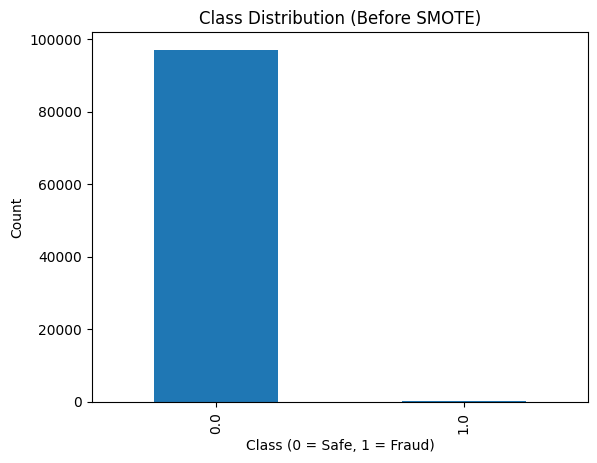

In [28]:
# ==========================================
# 2A. CLASS DISTRIBUTION
# ==========================================

plt.figure()
df['isFraud'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Before SMOTE)")
plt.xlabel("Class (0 = Safe, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

In [29]:
# ==========================================
# 2B. DATA PREPROCESSING
# ==========================================

# Drop useless columns
df = df.drop(['nameOrig', 'nameDest'], axis=1)

# Encode type
df = pd.get_dummies(df, columns=['type'], drop_first=True)

# Feature engineering
df['balance_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['dest_balance_diff'] = df['newbalanceDest'] - df['oldbalanceDest']
df['error_balance_orig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['error_balance_dest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# Drop leakage
df = df.drop(['isFlaggedFraud'], axis=1)

# Remove NaN
df = df.dropna(subset=['isFraud'])

print("✅ Preprocessing Done!")

✅ Preprocessing Done!


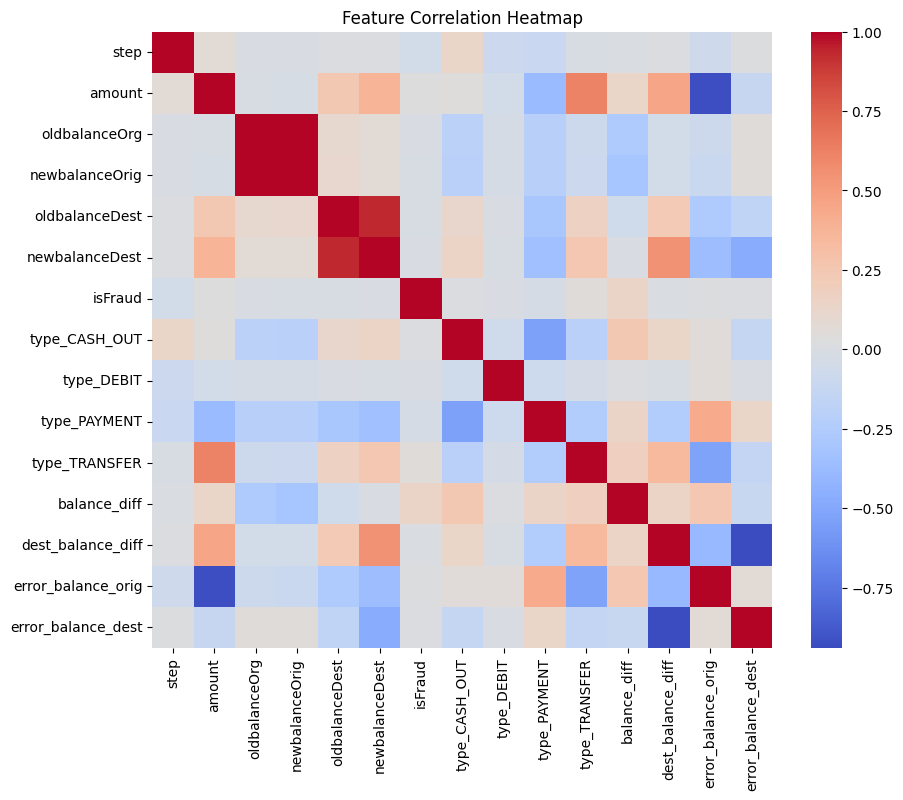

In [30]:
# ==========================================
# 3A. CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [31]:
# ==========================================
# 3B. FEATURES & TARGET
# ==========================================

X = df.drop('isFraud', axis=1)
y = df['isFraud']

print("Before SMOTE:\n", y.value_counts())

Before SMOTE:
 isFraud
0.0    97110
1.0      114
Name: count, dtype: int64


In [53]:
# ==========================================
# 4. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [60]:
print("X_train shape:", X_train.shape)
print("y_train distribution:\n", y_train.value_counts())

X_train shape: (15556, 14)
y_train distribution:
 isFraud
0.0    15538
1.0       18
Name: count, dtype: int64


In [59]:
# ==========================================
# 5. HANDLE IMBALANCE USING SMOTE
# ==========================================

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:\n", y_train_res.value_counts())

After SMOTE:
 isFraud
0.0    15538
1.0    15538
Name: count, dtype: int64


In [35]:
# ==========================================
# REDUCE DATA SIZE (IMPORTANT)
# ==========================================

df_sample = df.sample(frac=0.2, random_state=42)  # take 20%

X = df_sample.drop('isFraud', axis=1)
y = df_sample['isFraud']

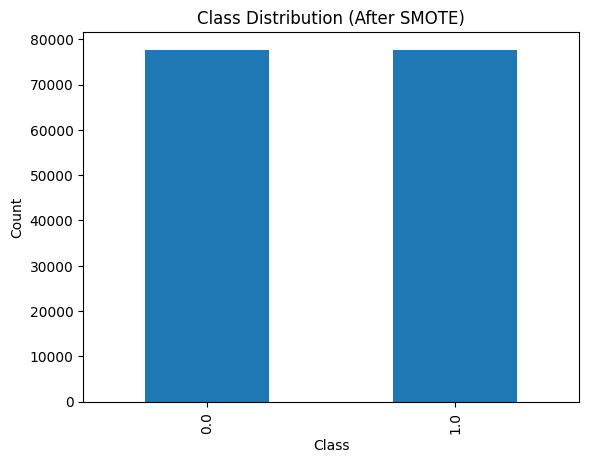

In [36]:
# ==========================================
# 6A. CLASS DISTRIBUTION AFTER SMOTE
# ==========================================

plt.figure()
pd.Series(y_train_res).value_counts().plot(kind='bar')
plt.title("Class Distribution (After SMOTE)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [37]:
# ==========================================
# 6B. SCALING
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [38]:
# ==========================================
# 7A. TRAIN LOGISTIC REGRESSION
# ==========================================

print("🚀 Training Logistic Regression...")

lr = LogisticRegression(max_iter=500)

lr.fit(X_train_scaled, y_train_res)

print("✅ Logistic Regression Done!")

🚀 Training Logistic Regression...
✅ Logistic Regression Done!


In [39]:
# ==========================================
# 7B. TRAIN RANDOM FOREST
# ==========================================

print("🚀 Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)

print("✅ Random Forest Done!")

🚀 Training Random Forest...
✅ Random Forest Done!


In [40]:
# ==========================================
# 7C. TRAIN GRADIENT BOOSTING
# ==========================================

print("🚀 Training Gradient Boosting...")

gb = GradientBoostingClassifier(
    n_estimators=50,
    random_state=42
)

gb.fit(X_train_scaled, y_train_res)

print("✅ Gradient Boosting Done!")

🚀 Training Gradient Boosting...
✅ Gradient Boosting Done!


In [42]:
# ==========================================
# 8A. MODEL EVALUATION
# ==========================================

lr_pred = lr.predict(X_test_scaled)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test_scaled)

print("📊 MODEL EVALUATION\n")

print("🔹 Accuracy:")
print("LR:", accuracy_score(y_test, lr_pred))
print("RF:", accuracy_score(y_test, rf_pred))
print("GB:", accuracy_score(y_test, gb_pred))

print("\n📋 Random Forest Report:\n")
print(classification_report(y_test, rf_pred))

📊 MODEL EVALUATION

🔹 Accuracy:
LR: 0.978400617125225
RF: 0.999485728979172
GB: 0.9993314476729236

📋 Random Forest Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     19422
         1.0       0.74      0.87      0.80        23

    accuracy                           1.00     19445
   macro avg       0.87      0.93      0.90     19445
weighted avg       1.00      1.00      1.00     19445



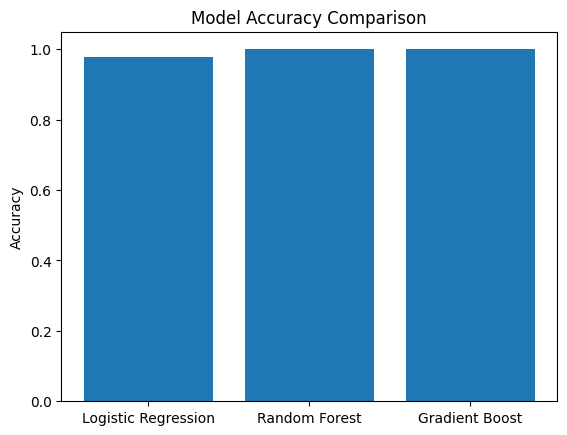

In [43]:
# ==========================================
# 8B. MODEL ACCURACY COMPARISON
# ==========================================

models = ['Logistic Regression', 'Random Forest', 'Gradient Boost']
accuracy = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, gb_pred)
]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

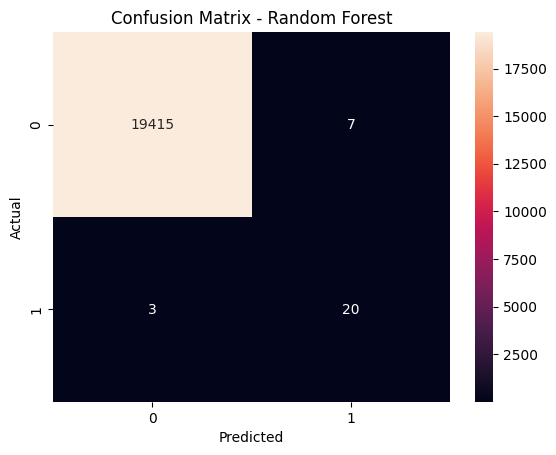

In [44]:
# ==========================================
# 8C: CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, rf_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

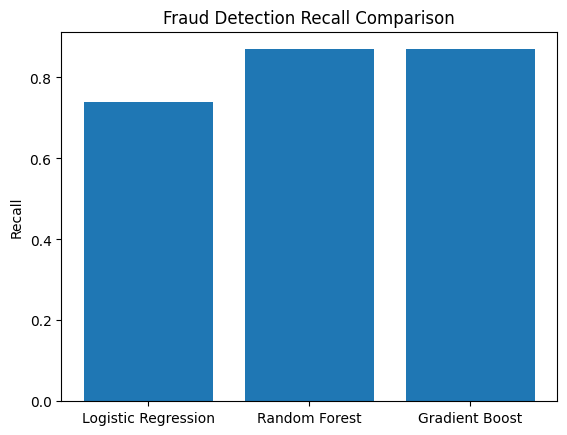

In [45]:
# ==========================================
# 8D. FRAUD RECALL COMPARISON
# ==========================================

recall = [
    recall_score(y_test, lr_pred),
    recall_score(y_test, rf_pred),
    recall_score(y_test, gb_pred)
]

plt.figure()
plt.bar(models, recall)
plt.title("Fraud Detection Recall Comparison")
plt.ylabel("Recall")
plt.show()

In [46]:
# ==========================================
# 9. MODEL RANKING
# ==========================================

models = {
    "LR": lr_pred,
    "RF": rf_pred,
    "GB": gb_pred
}

results = {}

for name, pred in models.items():
    results[name] = f1_score(y_test, pred)

sorted_models = sorted(results.items(), key=lambda x: x[1], reverse=True)

print("\n🏆 MODEL RANKING:")
for i, (model, score) in enumerate(sorted_models, 1):
    print(f"{i}. {model} → {score:.2f}")

best_model = sorted_models[0][0]
print("\n✅ BEST MODEL:", best_model)


🏆 MODEL RANKING:
1. RF → 0.80
2. GB → 0.75
3. LR → 0.07

✅ BEST MODEL: RF


In [47]:
# ==========================================
# 10A. FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance.head(10))

               Feature  Importance
12  error_balance_orig    0.237953
0                 step    0.202820
10        balance_diff    0.116624
9        type_TRANSFER    0.116380
3       newbalanceOrig    0.081992
8         type_PAYMENT    0.071542
2        oldbalanceOrg    0.047476
4       oldbalanceDest    0.032290
6        type_CASH_OUT    0.022894
1               amount    0.020702


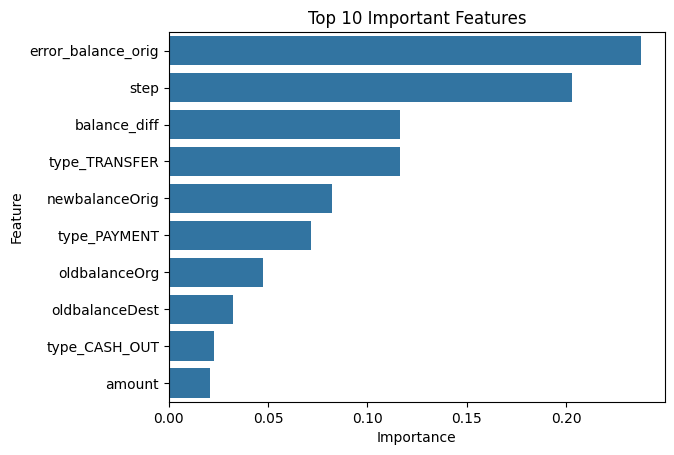

In [48]:
# ==========================================
# 10B. FEATURE IMPORTANCE PLOT
# ==========================================

plt.figure()
sns.barplot(x='Importance', y='Feature', data=importance.head(10))
plt.title("Top 10 Important Features")
plt.show()

In [51]:
# ==========================================
# 11. USER INPUT
# ==========================================

print("\n📌 ENTER TRANSACTION DETAILS:\n")

user_data = {}

raw_features = [
    'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'
]

for feature in raw_features:
    val = float(input(f"Enter {feature}: "))
    user_data[feature] = val

user_df = pd.DataFrame([user_data])

# Feature engineering
user_df['balance_diff'] = user_df['oldbalanceOrg'] - user_df['newbalanceOrig']
user_df['dest_balance_diff'] = user_df['newbalanceDest'] - user_df['oldbalanceDest']
user_df['error_balance_orig'] = user_df['oldbalanceOrg'] - user_df['amount'] - user_df['newbalanceOrig']
user_df['error_balance_dest'] = user_df['oldbalanceDest'] + user_df['amount'] - user_df['newbalanceDest']

# Align columns
user_df = user_df[X.columns]


📌 ENTER TRANSACTION DETAILS:

Enter step: 10
Enter amount: 90000
Enter oldbalanceOrg: 90000
Enter newbalanceOrig: 0
Enter oldbalanceDest: 0
Enter newbalanceDest: 90000
Enter type_CASH_OUT: 0
Enter type_DEBIT: 0
Enter type_PAYMENT: 0
Enter type_TRANSFER: 1


In [52]:
# ==========================================
# 12. FRAUD PREDICTION
# ==========================================

prob = rf.predict_proba(user_df)[0][1]

# 🔴 ADD THIS LINE HERE
print(f"Raw Probability: {prob}")

threshold = 0.01

prediction = "FRAUD 🚨" if prob > threshold else "SAFE ✅"

print("\n" + "="*50)
print("🔍 FRAUD ANALYSIS RESULT")
print("="*50)

print(f"Prediction: {prediction}")
print(f"Fraud Risk Probability: {prob*100:.2f}%")

Raw Probability: 0.5768036212892064

🔍 FRAUD ANALYSIS RESULT
Prediction: FRAUD 🚨
Fraud Risk Probability: 57.68%
